In [41]:
### importing the required libraries
using CSV
using DataFrames
using Statistics
using Plots
using DataStructures  # For the Counter function

In [42]:
module Read
    include("Read_data_files.jl")
end

module Check
    include("Check_files_exist.jl")
end

Main.Check

In [43]:
### change this to the job id for the experiment you want to analyze
## or the name you want to give the folder where all the extracted data files will be stored
JOB_ID = 67114515
### make sure to write dispersal parameters as floats to keep file name consistent ###

## vary these for different dispersal scenarios
gamma = 0.15    # dispersal rate from release site to household
rho = 0.33      # rate visit the households
tau = 0.33      # rate leave the households
alpha = 0.1     # dispersal rate of females moving from household directly to another household

num_simulations = 100  # number of realisations of SSA to run, 10,000 is a good number for the paper
rel_type = "relhhold"

"relhhold"

In [44]:
# Define parameters dictionary
fem_w0 = 0  # how many wildtypes and infected mosquitoes starting off with
male_w0 = 0
fem_m0 = 8
male_m0 = 8
m_free0 = 0 # no. of free wild-type
w_free0 = 0 # no. of free Wolbachia

# model parameters
phi = 0.85      # wolbachia fitness effect on birth rate
K = 30          # carrying capacity of mosquitoes per household
d = 12/100      # death rate of mosquitoes
k = 0.3         # larval density parameter
h = 0.19*100^k  # larval density parameter
b = 0.54        # per capita birth rate of mosquitoes (wildtypes)
H = 100         # number of households
u = 1           # vertical transmission probability
v = 1           # CI effect, proportion of non-viable offspring from infected male and wildtype female birth

rel_t = 150   # initial release time
delta_rel = 0 # time in days between releases, currently set to a single release inside the SSA code
## remember this is per household for the household releases so should use smaller release numbers
## currently set for community wide release
rel_size = 8 # total number of Wolbachia-infected mosquitoes released into the community

t_start = 0    
t_end = 1000   # start time and end time (days) of simulation

result_length = length(t_start:t_end) # number of time points to store results
weeks = round(Int,result_length/7)    # number of weeks to store results

parameters = Dict(           # dictionary of parameters
    :fem_m0 => fem_m0,
    :male_m0 => male_m0,
    :fem_w0 => fem_w0,
    :male_w0 => male_w0,
    :m_free0 => m_free0,
    :w_free0 => w_free0,
    :rho => rho,
    :phi => phi,
    :b => b,
    :K => K,
    :d => d,
    :h => h,
    :k => k,
    :u => u,
    :v => v,
    :tau => tau,
    :H => H,
    :t_start => t_start,
    :t_end => t_end,
    :seed => 1234,
    :delta_rel => delta_rel,
    :rel_size => rel_size,
    :gamma => gamma,
    :alpha => alpha,
    :rel_t => rel_t
)

Dict{Symbol, Real} with 25 entries:
  :b        => 0.54
  :alpha    => 0.1
  :rel_size => 8
  :gamma    => 0.15
  :m_free0  => 0
  :rho      => 0.33
  :t_start  => 0
  :h        => 0.756404
  :rel_t    => 150
  :male_w0  => 0
  :fem_m0   => 8
  :K        => 30
  :phi      => 0.85
  :fem_w0   => 0
  :d        => 0.12
  :k        => 0.3
  :v        => 1
  :u        => 1
  :male_m0  => 8
  ⋮         => ⋮

In [45]:
## Read in the total wildtype and Wolbachia-infected mosquito populations data, 
## as well as free population only versions
par_dict = Dict(
    :rho => rho,
    :tau => tau,
    :alpha => alpha,
    :gamma => gamma,
    :rel_type => rel_type,
    :H => H,
    :rel_size => rel_size,
    :rel_t => rel_t
)
    
m_array, w_array, free_m_array, free_w_array = Read.read_data(par_dict, JOB_ID)

([1600.0 1600.0 … 1600.0 1600.0; 1612.0 1612.0 … 1600.0 1606.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 1174.0 1205.0 … 1345.0 1408.0; 1194.0 1196.0 … 1331.0 1397.0], [0.0 0.0 … 0.0 0.0; 167.0 203.0 … 181.0 203.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 244.0 255.0 … 269.0 298.0; 244.0 261.0 … 290.0 303.0])

In [46]:
alpha_str, gamma_str, rho_str, tau_str = Read.str_convert(alpha, gamma, rho, tau)

arr_prop_tot = nothing
mw_cts = zeros(weeks)

for i in 1:num_simulations
    df_fem_m = Check.check_and_read_file("fem_m_hholds", i, alpha_str, gamma_str, rho_str, tau_str, H, rel_t, rel_size, rel_type, JOB_ID)
    df_male_m = Check.check_and_read_file("male_m_hholds", i, alpha_str, gamma_str, rho_str, tau_str, H, rel_t, rel_size, rel_type, JOB_ID)
    df_fem_w = Check.check_and_read_file("fem_w_hholds", i, alpha_str, gamma_str, rho_str, tau_str, H, rel_t, rel_size, rel_type, JOB_ID)
    df_male_w = Check.check_and_read_file("male_w_hholds", i, alpha_str, gamma_str, rho_str, tau_str, H, rel_t, rel_size, rel_type, JOB_ID)
    # Convert DataFrame to array
    arr_fem_m = Matrix(df_fem_m)
    arr_male_m = Matrix(df_male_m)
    arr_fem_w = Matrix(df_fem_w)
    arr_male_w = Matrix(df_male_w)

    # want the number of households at each time point that have only have one wildtype and atleast 3 W-infected
    arr_m = arr_fem_m .+ arr_male_m
    arr_w = arr_fem_w .+ arr_male_w
    m_inds = [findall(x -> x == 1, arr_m[row, :]) for row in 1:size(arr_m, 1)]
    w_inds = [findall(x -> x >= 5, arr_w[row, :]) for row in 1:size(arr_w, 1)]
    # Count the number of common entries for each pair of w_inds and m_inds
    mw_cts .+= [length(intersect(w_inds[j], m_inds[j])) for j in 1:length(w_inds)]
end  

In [47]:
mw_cts_h = mw_cts

143-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 ⋮
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

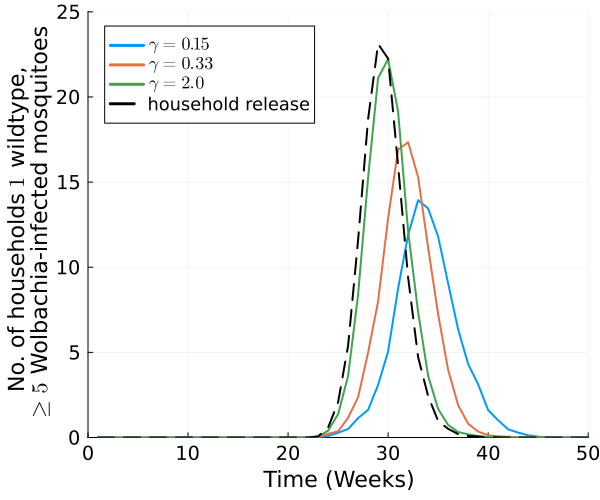

In [58]:
p=plot(mw_cts_015./num_simulations, xlabel="Time (Weeks)", ylabel="No. of households \$1\$ wildtype, 
\$\\geq 5\$ Wolbachia-infected mosquitoes", titlefont=font(14), label="\$\\gamma = 0.15\$",
size = (600, 500),
guidefont = font(15), 
tickfont = font(13),
grid = true,
linewidth=2)
plot!(p,mw_cts_033./num_simulations, label="\$\\gamma = 0.33\$",
size = (600, 500),
guidefont = font(15), 
tickfont = font(13),
grid = true,
linewidth=2)
plot!(p,mw_cts_2./num_simulations, label="\$\\gamma = 2.0\$",
size = (600, 500),
guidefont = font(15), 
tickfont = font(13),
grid = true,
linewidth=2)
plot!(p,mw_cts_h./num_simulations, label="household release", linecolor=:black, linestyle=:dash,
size = (600, 500),
guidefont = font(15), 
tickfont = font(13),
grid = true,
linewidth=2)
plot!(xlim=(0,50))
plot!(ylim=(0,25),size = (600, 500),
guidefont = font(15), 
tickfont = font(13),
grid = true,
linewidth=2,
legendfont=font(12),
legend=:topleft)
savefig(p, "low_wilds_01_gammas_033_033_100__150_800_relcom.pdf")
p